In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = "C:/Users/Lenovo/Desktop/Top Mentor/Assignment/need to do/9 Clustering/crime_data.csv"
df = pd.read_csv(data)
df.head()

,Unnamed: 0,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6


In [3]:
df.shape

(50, 5)

In [4]:
df.columns

Index(['Unnamed: 0', 'Murder', 'Assault', 'UrbanPop', 'Rape'], dtype='object')

In [6]:
df = df.rename(columns={'Unnamed: 0': 'State'})

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   State     50 non-null     object 
 1   Murder    50 non-null     float64
 2   Assault   50 non-null     int64  
 3   UrbanPop  50 non-null     int64  
 4   Rape      50 non-null     float64
dtypes: float64(2), int64(2), object(1)
memory usage: 2.1+ KB


In [8]:
df.isnull().sum()

State       0
Murder      0
Assault     0
UrbanPop    0
Rape        0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe()

,Murder,Assault,UrbanPop,Rape
count,50.00000,50.000000,50.000000,50.000000
mean,7.78800,170.760000,65.540000,21.232000
std,4.35551,83.337661,14.474763,9.366385
min,0.80000,45.000000,32.000000,7.300000
25%,4.07500,109.000000,54.500000,15.075000
50%,7.25000,159.000000,66.000000,20.100000
75%,11.25000,249.000000,77.750000,26.175000
max,17.40000,337.000000,91.000000,46.000000


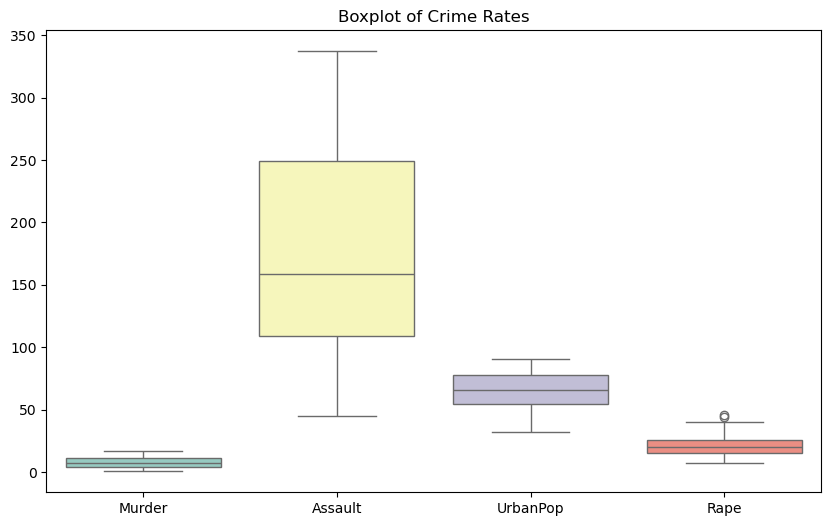

In [12]:
# 1. Boxplot - Look at the 'Assault' column specifically; notice how much 
# larger its values are compared to Murder. This is why we scale later!
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, palette="Set3")
plt.title("Boxplot of Crime Rates")
plt.savefig("C:/Users/Lenovo/Desktop/Top Mentor/Assignment/need to do/9 Clustering/Crime Data graphs/Boxplot.png")
plt.show()

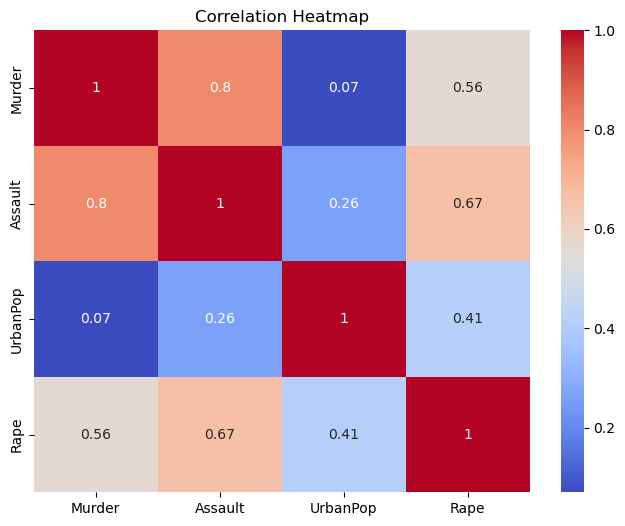

In [14]:
# 2. Heatmap - Check if Murder and Assault are highly correlated.
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.savefig("C:/Users/Lenovo/Desktop/Top Mentor/Assignment/need to do/9 Clustering/Crime Data graphs/HeatMap.png")
plt.show()

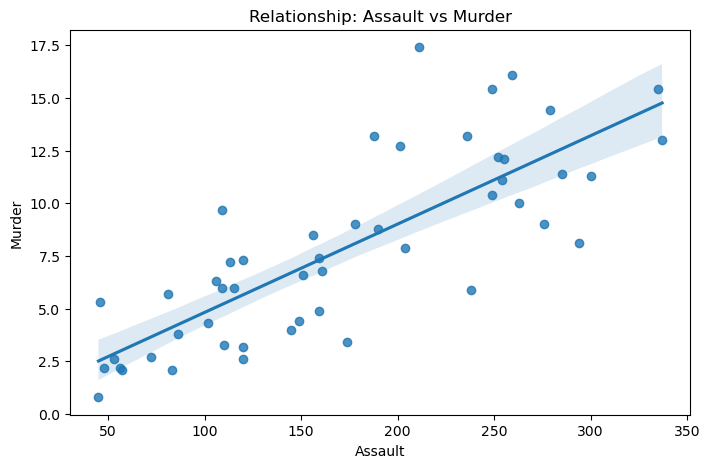

In [15]:
# 3. Regression Plot - Assault vs Murder
plt.figure(figsize=(8, 5))
sns.regplot(x='Assault', y='Murder', data=df)
plt.title("Relationship: Assault vs Murder")
plt.savefig("C:/Users/Lenovo/Desktop/Top Mentor/Assignment/need to do/9 Clustering/Crime Data graphs/Regression plot.png")
plt.show()

In [16]:
from sklearn.preprocessing import StandardScaler

# We drop 'State' only for the math, or use numeric_only
# If 'State' is your index, df.values will only pick the numbers
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df.drop('State', axis=1) if 'State' in df.columns else df)

# Convert back to a DataFrame to keep it tidy
df_scaled_final = pd.DataFrame(df_scaled, columns=['Murder', 'Assault', 'UrbanPop', 'Rape'])
df_scaled_final.head()

,Murder,Assault,UrbanPop,Rape
0,1.255179,0.790787,-0.526195,-0.003451
1,0.513019,1.118060,-1.224067,2.509424
2,0.072361,1.493817,1.009122,1.053466
3,0.234708,0.233212,-1.084492,-0.186794
4,0.281093,1.275635,1.776781,2.088814


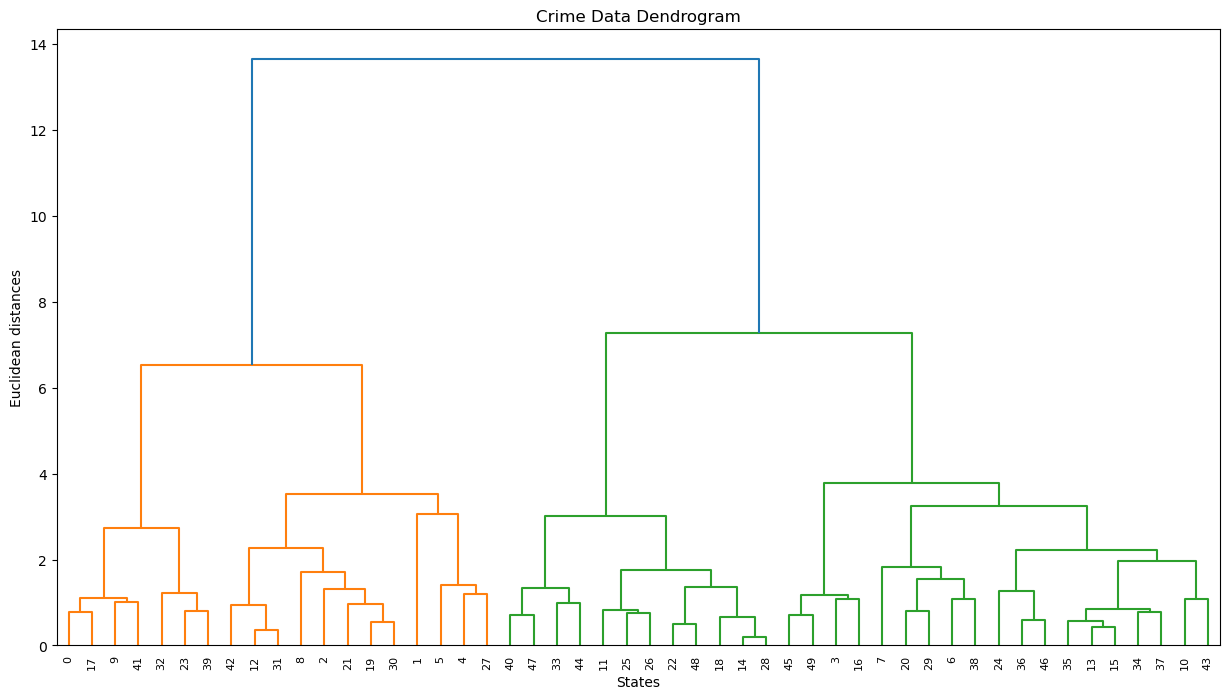

In [17]:
import scipy.cluster.hierarchy as sch

plt.figure(figsize=(15, 8))
plt.title('Crime Data Dendrogram')
plt.xlabel('States')
plt.ylabel('Euclidean distances')

# Using 'ward' linkage to minimize the variance within clusters
dendrogram = sch.dendrogram(sch.linkage(df_scaled, method='ward'))

# Save your work!
plt.savefig("C:/Users/Lenovo/Desktop/Top Mentor/Assignment/need to do/9 Clustering/Crime Data graphs/Dendrogram.png")
plt.show()

In [19]:
from sklearn.cluster import AgglomerativeClustering

# 1. Initialize the model (using 3 clusters)
# Note: Changed 'affinity' to 'metric'
hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')

# 2. Fit and Predict
y_hc = hc.fit_predict(df_scaled)

# 3. Add the labels back to your original DataFrame 'df'
df['cluster_HC'] = y_hc

# 4. Check the distribution
print("Count of states in each cluster:")
print(df['cluster_HC'].value_counts())

Count of states in each cluster:
cluster_HC
0    19
1    19
2    12
Name: count, dtype: int64


In [20]:
# Group by the new cluster ID and find the average of crime rates
crime_analysis = df.groupby('cluster_HC').mean(numeric_only=True)
print(crime_analysis)

               Murder     Assault   UrbanPop       Rape
cluster_HC                                             
0           12.331579  259.315789  68.315789  29.215789
1            6.210526  142.052632  71.263158  19.184211
2            3.091667   76.000000  52.083333  11.833333


The Murder Gap: Murder rates in Cluster 0 are 4x higher than in Cluster 2.

The Urban Factor: Even though Cluster 1 is more urbanized than Cluster 0, it is significantly safer, suggesting that crime is not purely a result of population density.

#Kmeans

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

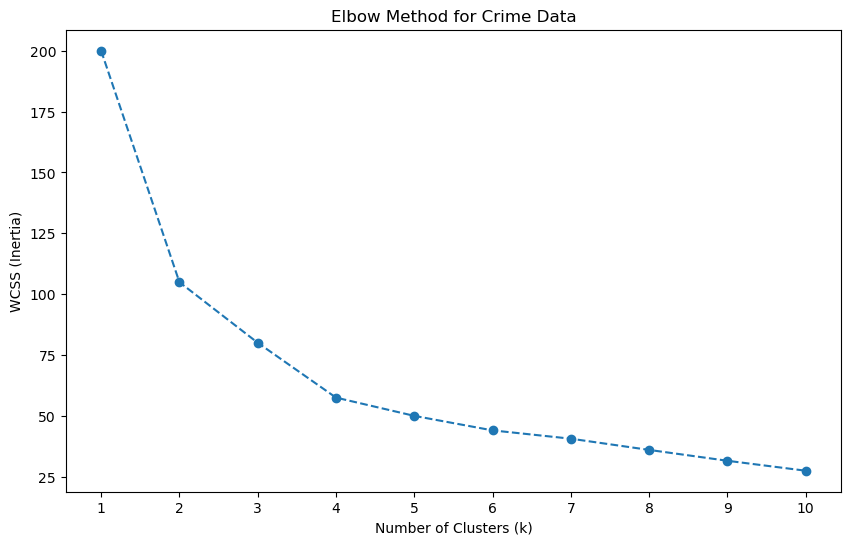

In [21]:
from sklearn.cluster import KMeans

wcss = []
# Testing K values from 1 to 10
for i in range(1, 11):
    # n_init=10 is the standard to ensure the algorithm runs multiple times
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Crime Data')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1, 11))
plt.show()

In [22]:
from sklearn.cluster import KMeans

# 1. Initialize and fit the model
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(df_scaled)

# 2. Add the K-Means labels to your dataframe
# I'll call it 'cluster_Kmeans' to distinguish it from 'cluster_HC'
df['cluster_Kmeans'] = kmeans.labels_

# 3. Quick check of the state distribution
print("Count of states per K-Means cluster:")
print(df['cluster_Kmeans'].value_counts())

Count of states per K-Means cluster:
cluster_Kmeans
0    16
3    13
2    13
1     8
Name: count, dtype: int64


C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [23]:
# Group by the K-Means cluster and find the mean
kmeans_analysis = df.groupby('cluster_Kmeans').mean(numeric_only=True)
print(kmeans_analysis)

                   Murder     Assault   UrbanPop       Rape  cluster_HC
cluster_Kmeans                                                         
0                5.656250  138.875000  73.875000  18.781250    1.000000
1               13.937500  243.625000  53.750000  21.412500    0.125000
2                3.600000   78.538462  52.076923  12.176923    1.923077
3               10.815385  257.384615  76.000000  33.192308    0.076923


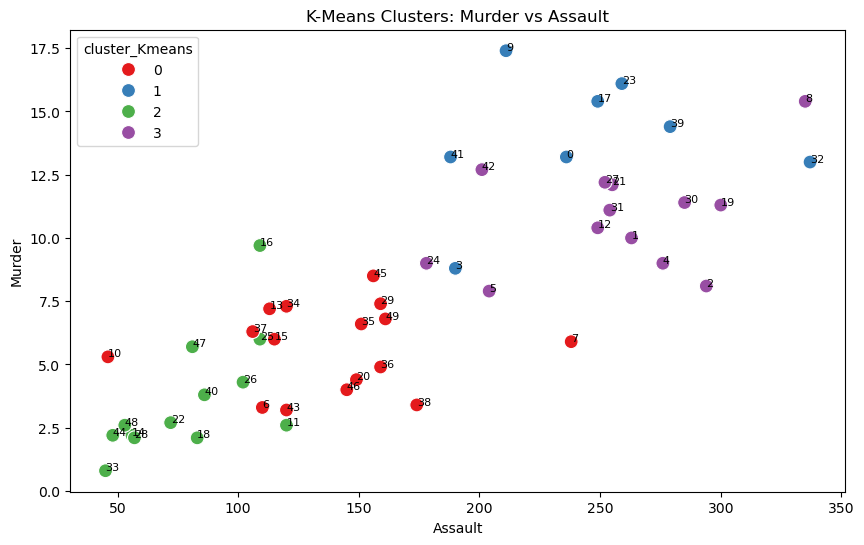

In [24]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Assault', y='Murder', hue='cluster_Kmeans', palette='Set1', s=100)

# Add State names to the dots (optional but looks great for 50 states)
for i in range(df.shape[0]):
    plt.text(df.Assault[i], df.Murder[i], df.index[i], fontsize=8)

plt.title('K-Means Clusters: Murder vs Assault')
plt.show()

The Core Segments: Crime Profiles: 

Cluster 1 (The High-Violence States): This group has the highest Murder rates (avg ~14) despite having a lower urban population than the major hubs.
Action: These regions face intense violent crime challenges. Action should focus on high-priority violent crime intervention and community-based de-escalation programs.

Cluster 3 (The Dangerous Urban Hubs): This group has the highest Urban Population (avg ~76%) and the highest Assault and Rape rates.
Action: Crime here is likely driven by high density. Action should focus on increasing public safety infrastructure, better street lighting, and higher police presence in dense metropolitan corridors.

Cluster 0 (The Stable Metropolitan States): These states are highly urbanized (avg ~74%) but manage to keep Murder and Assault rates significantly lower than Cluster 3.
Action: These are successful "large-population" models. Action should focus on studying their social programs and maintaining current community policing strategies that are clearly working.

Cluster 2 (The Safe Rural States): This is your "Low-Risk" group. They have the lowest crime rates across every single category and the lowest urbanization.
Action: These are the safest regions in the dataset. Action should focus on maintaining rural community stability and lower-intensity, community-focused patrol.